In [1]:
import pandas as pd 
import numpy as np

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
from sklearn.tree import DecisionTreeClassifier

In [6]:
X,y = make_classification(n_features=5, n_redundant=0, n_informative=5,n_clusters_per_class=1)
X.shape

(100, 5)

In [7]:
df = pd.DataFrame(X,columns=['col1','col2','col3','col4','col5'])
df['target'] = y
print(df.shape)
df.head()

(100, 6)


,col1,col2,col3,col4,col5,target
0,0.383849,1.300966,-0.269021,0.392088,-1.284962,1
1,-4.015501,-1.095253,3.236555,1.036000,2.114050,1
2,0.972608,0.081944,-0.243160,1.248811,-1.359657,0
3,-1.245396,0.944522,1.941752,1.411470,0.312542,1
4,0.318896,0.933705,-0.515324,1.356986,-2.561178,0


In [9]:
# function for row sampling
def row_sampling(percent,df):
    return df.sample(int(percent*df.shape[0]),replace=True)

In [10]:
# function for column sampling
import random
def col_sampling(percent,df):
      cols = random.sample(df.columns.tolist()[:-1],int(percent*(df.shape[1]-1)))
      new_df = df[cols]
      new_df['target'] = df['target']
      return new_df

In [11]:
def combinedSam(percentcol,percentrow,df):
    newdf = row_sampling(percentrow,df)
    return col_sampling(percentcol,newdf) 

In [18]:
df1 = row_sampling(0.2,df)
df2 = row_sampling(0.2,df)
df3 = row_sampling(0.2,df)

In [19]:
df1.shape

(20, 6)

In [20]:
dt1 = DecisionTreeClassifier()
dt2 = DecisionTreeClassifier()
dt3 = DecisionTreeClassifier()

In [27]:
dt1.fit(df1.iloc[:,0:5:],df1.iloc[:,-1])
dt2.fit(df2.iloc[:,0:5:],df2.iloc[:,-1])
dt3.fit(df3.iloc[:,0:5:],df3.iloc[:,-1])

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

[Text(0.6, 0.8333333333333334, 'x[0] <= 0.625\ngini = 0.42\nsamples = 20\nvalue = [6, 14]'),
 Text(0.4, 0.5, 'x[4] <= -1.838\ngini = 0.124\nsamples = 15\nvalue = [1, 14]'),
 Text(0.5, 0.6666666666666667, 'True  '),
 Text(0.2, 0.16666666666666666, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.6, 0.16666666666666666, 'gini = 0.0\nsamples = 14\nvalue = [0, 14]'),
 Text(0.8, 0.5, 'gini = 0.0\nsamples = 5\nvalue = [5, 0]'),
 Text(0.7, 0.6666666666666667, '  False')]

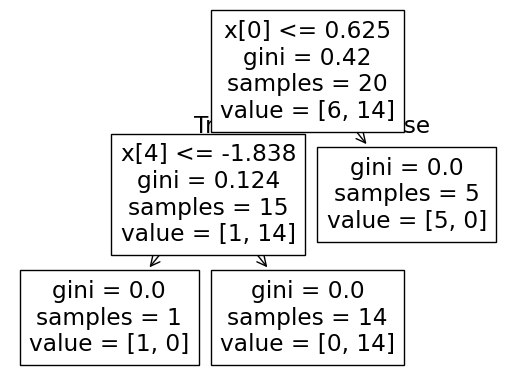

In [28]:
from sklearn.tree import plot_tree
plot_tree(dt1)

[Text(0.6, 0.8333333333333334, 'x[0] <= 0.534\ngini = 0.5\nsamples = 20\nvalue = [10, 10]'),
 Text(0.4, 0.5, 'x[2] <= -0.708\ngini = 0.165\nsamples = 11\nvalue = [1, 10]'),
 Text(0.5, 0.6666666666666667, 'True  '),
 Text(0.2, 0.16666666666666666, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.6, 0.16666666666666666, 'gini = 0.0\nsamples = 10\nvalue = [0, 10]'),
 Text(0.8, 0.5, 'gini = 0.0\nsamples = 9\nvalue = [9, 0]'),
 Text(0.7, 0.6666666666666667, '  False')]

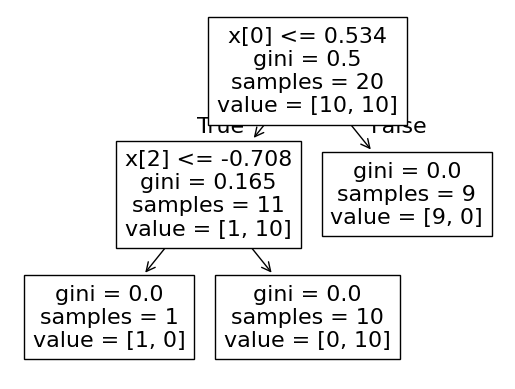

In [29]:
plot_tree(dt2)

[Text(0.6666666666666666, 0.875, 'x[4] <= 0.271\ngini = 0.495\nsamples = 20\nvalue = [9, 11]'),
 Text(0.5, 0.625, 'x[3] <= 0.653\ngini = 0.298\nsamples = 11\nvalue = [9, 2]'),
 Text(0.5833333333333333, 0.75, 'True  '),
 Text(0.3333333333333333, 0.375, 'x[3] <= -0.888\ngini = 0.5\nsamples = 4\nvalue = [2, 2]'),
 Text(0.16666666666666666, 0.125, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.5, 0.125, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.6666666666666666, 0.375, 'gini = 0.0\nsamples = 7\nvalue = [7, 0]'),
 Text(0.8333333333333334, 0.625, 'gini = 0.0\nsamples = 9\nvalue = [0, 9]'),
 Text(0.75, 0.75, '  False')]

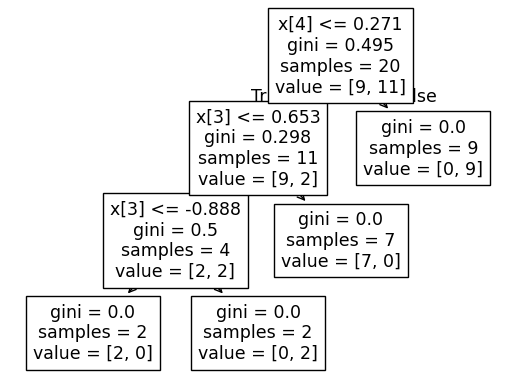

In [30]:
plot_tree(dt3)

In [31]:
df1

,col1,col2,col3,col4,col5,target
60,-0.532868,-2.805098,-0.424157,-0.579143,1.477402,1
85,-0.358193,-1.783642,0.026189,0.099054,0.172302,1
92,2.131406,0.553938,-1.759865,-0.812854,-4.380193,0
32,-1.526180,0.464284,0.734111,0.567939,1.780650,1
7,-1.572014,-1.505335,2.943135,1.969067,0.972964,1
36,0.222900,-1.295624,-0.346510,0.733684,0.664738,1
41,0.565588,2.905395,1.094782,3.519974,-1.120984,1
57,-0.805157,-1.698304,1.175905,0.866835,0.329500,1
63,2.028902,-2.692779,-0.291636,1.281586,0.232579,0
40,-0.654166,0.433167,2.156871,4.918383,1.887745,1


In [33]:
print(dt1.predict(np.array([-0.532868,-2.805098,-0.424157,-0.579143,1.477402]).reshape(1,5)))
print(dt2.predict(np.array([-0.532868,-2.805098,-0.424157,-0.579143,1.477402]).reshape(1,5)))
print(dt3.predict(np.array([-0.532868,-2.805098,-0.424157,-0.579143,1.477402]).reshape(1,5)))

[1]
[1]
[1]


c:\Users\KIIT0001\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\KIIT0001\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\KIIT0001\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
